## C. Unsupervised Learning

### 2.8 K-Means

> **做什么**：将样本划分为K个簇，使簇内距离最小  
> **经典案例**：客户分群 + 肘部法则选K

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 生成模拟客户数据（4个客户群）
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.2, random_state=42)

# ====== 肘部法则：选最优K值 ======
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)  # 簇内平方和
    print(f"K={k}, 惯性={km.inertia_:.1f}, 轮廓系数={silhouette_score(X, km.labels_):.3f}")

# 选择K=4进行最终聚类
model = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = model.fit_predict(X)
print(f"\n最终K=4, 轮廓系数: {silhouette_score(X, labels):.3f}")
print(f"簇中心:\n{model.cluster_centers_}")

# 关键参数：n_clusters(K值), init='k-means++'(智能初始化), n_init(重复次数)

K=2, 惯性=16164.6, 轮廓系数=0.584
K=3, 惯性=3803.8, 轮廓系数=0.740
K=4, 惯性=1366.4, 轮廓系数=0.748
K=5, 惯性=1232.8, 轮廓系数=0.628
K=6, 惯性=1105.7, 轮廓系数=0.508
K=7, 惯性=982.2, 轮廓系数=0.465
K=8, 惯性=854.1, 轮廓系数=0.347
K=9, 惯性=787.1, 轮廓系数=0.348

最终K=4, 轮廓系数: 0.748
簇中心:
[[ 4.73821371  1.91399279]
 [-8.65017946  7.48183793]
 [-7.02523244 -6.90932713]
 [-2.62081897  9.10806483]]


### 2.9 Hierarchical Clustering

> **做什么**：自底向上逐步合并最相似的簇，形成树状结构  
> **经典案例**：鸢尾花层次聚类 + 树状图

调整兰德指数: 0.731


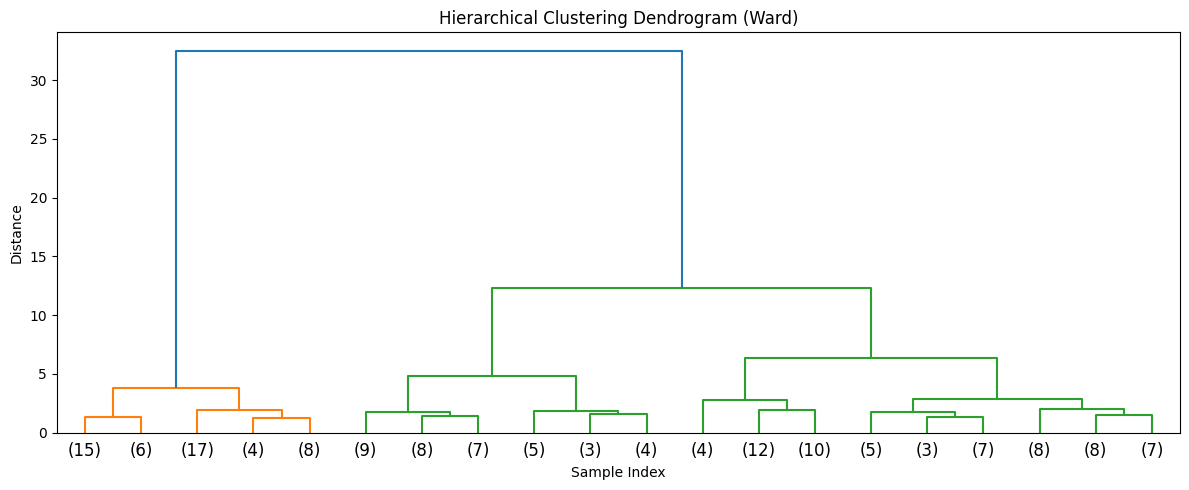

In [3]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
import matplotlib.pyplot as plt

# 加载鸢尾花数据
iris = load_iris()
X = iris.data

# 层次聚类（设3簇）
model = AgglomerativeClustering(n_clusters=3, linkage='ward')  # ward: 最小方差合并
labels = model.fit_predict(X)
print(f"调整兰德指数: {adjusted_rand_score(iris.target, labels):.3f}")

# 绘制树状图
Z = linkage(X, method='ward')  # 计算链接矩阵
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20)  # 只显示最后20次合并
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 2.10 PCA

> **做什么**：线性降维，保留最大方差方向  
> **经典案例**：手写数字64维->2维可视化


原始维度: 64, 降维后: 2
两个主成分解释方差比: [0.12033916 0.09561054]
累计解释方差: 0.216


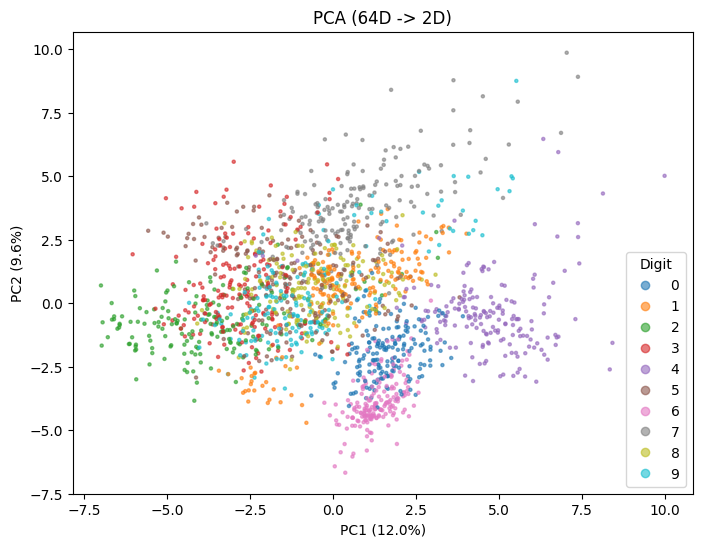

In [4]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 加载手写数字（64维特征）
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

# PCA降维到2维
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
print(f"原始维度: {X.shape[1]}, 降维后: 2")
print(f"两个主成分解释方差比: {pca.explained_variance_ratio_}")
print(f"累计解释方差: {pca.explained_variance_ratio_.sum():.3f}")

# 可视化
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=5, alpha=0.6)
plt.legend(*scatter.legend_elements(), title='Digit')
plt.title('PCA (64D -> 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.show()

# 关键参数：n_components(保留维度或0~1间的方差比例)

### 2.11 t-SNE

> **做什么**：非线性降维，保持局部邻域结构，适合可视化  
> **经典案例**：手写数字t-SNE可视化（与PCA对比）

D:\JupyterNotebook\test\work2\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
D:\JupyterNotebook\test\work2\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


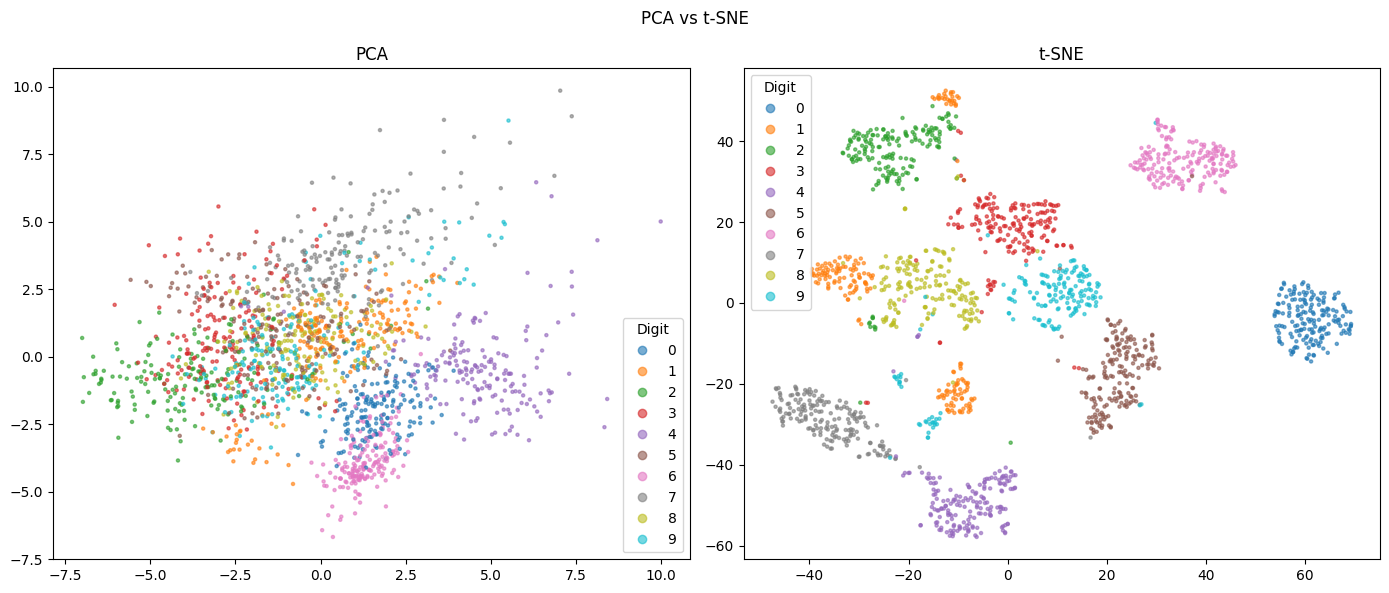

In [5]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

# PCA降维（先降到30维加速t-SNE）
X_pca30 = PCA(n_components=30).fit_transform(X)

# t-SNE降维到2维
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca30)

# 同时用PCA降到2维做对比
X_pca2 = PCA(n_components=2).fit_transform(X)

# 对比可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data_2d, title in [(axes[0], X_pca2, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    scatter = ax.scatter(data_2d[:, 0], data_2d[:, 1], c=y, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(title)
    ax.legend(*scatter.legend_elements(), title='Digit')
plt.suptitle('PCA vs t-SNE')
plt.tight_layout()
plt.show()

# 关键参数：perplexity(困惑度,5~50), n_iter(迭代次数), learning_rate